In [1]:
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('customer_churn_data.csv')

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [5]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [6]:
df['InternetService'] = df['InternetService'].fillna('')

In [7]:
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [8]:
print(df.duplicated().sum())

0


In [9]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [10]:
df.describe().round(2)

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,44.67,18.97,74.39,1404.36
std,288.82,9.80,18.89,25.71,1571.76
min,1.00,12.00,0.00,30.00,0.00
25%,250.75,38.00,5.00,52.36,345.22
50%,500.50,45.00,13.00,74.06,872.87
75%,750.25,51.00,26.00,96.10,1900.18
max,1000.00,83.00,122.00,119.96,12416.25


In [11]:
numeric_column_data = df.select_dtypes(include = ['number'])

In [12]:
numeric_column_data

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32
...,...,...,...,...,...
995,996,42,41,37.14,1522.74
996,997,62,9,80.93,728.37
997,998,51,15,111.72,1675.80
998,999,39,68,65.67,4465.56


In [13]:
numeric_column_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [14]:
# 1 strong corelation , -1 weak corelation

In [15]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [16]:
import matplotlib.pyplot as plt

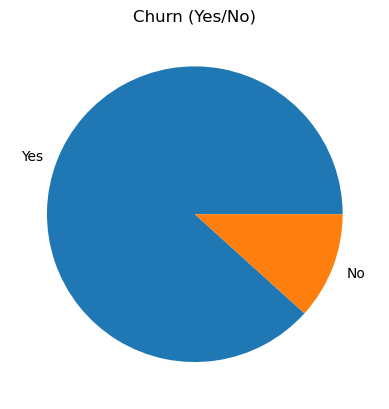

In [17]:
df['Churn'].value_counts().plot(kind = 'pie')
plt.title('Churn (Yes/No)')
plt.ylabel("")
plt.show()


In [18]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [19]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [20]:
df.groupby(['Churn','Gender'])['MonthlyCharges'].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [21]:
df.groupby('Churn')['Tenure'].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [22]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [23]:
df.groupby("Churn")['Age'].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

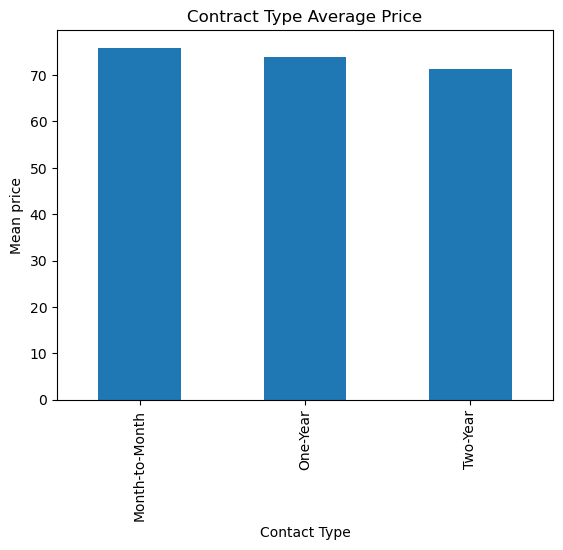

In [24]:
df.groupby('ContractType')['MonthlyCharges'].mean().plot(kind = 'bar')
plt.ylabel('Mean price')
plt.xlabel('Contact Type')
plt.title('Contract Type Average Price')
plt.show()

In [25]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


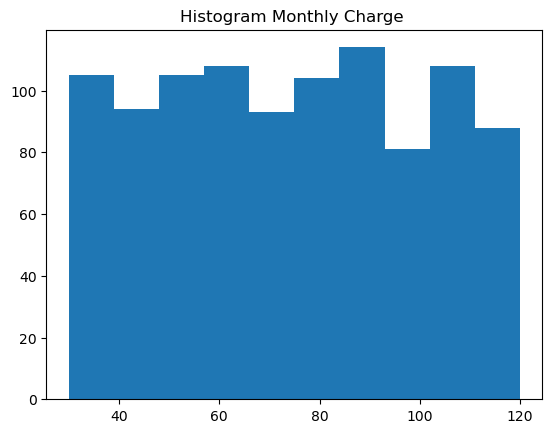

In [26]:
plt.hist(df['MonthlyCharges'])
plt.title('Histogram Monthly Charge ')
plt.show()

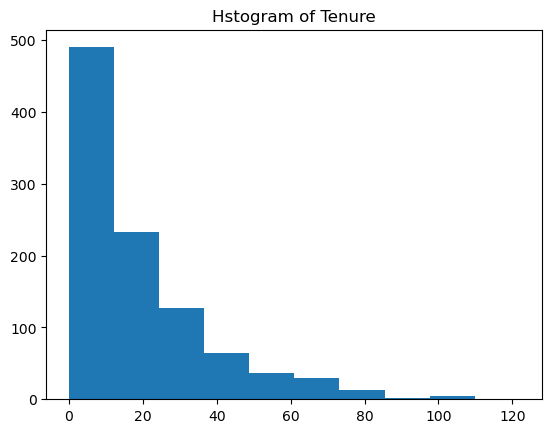

In [27]:
plt.hist(df['Tenure'])
plt.title('Hstogram of Tenure')
plt.show()

In [28]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [29]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [30]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [31]:
y = df['Churn']
X = df[['Age','Gender','Tenure','MonthlyCharges']]

In [32]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [33]:
y

0      Yes
1      Yes
2      Yes
3      Yes
4      Yes
      ... 
995    Yes
996    Yes
997    Yes
998    Yes
999    Yes
Name: Churn, Length: 1000, dtype: object

In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [35]:
X['Gender'] = le.fit_transform(X['Gender'])
y = le.fit_transform(y)

In [36]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,1,4,88.35
1,43,1,0,36.67
2,51,0,2,63.79
3,60,0,8,102.34
4,42,1,32,69.01


In [37]:
type(X['Gender'][0])

numpy.int64

In [38]:
type(y[0])

numpy.int64

In [39]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,1,4,88.35
1,43,1,0,36.67
2,51,0,2,63.79
3,60,0,8,102.34
4,42,1,32,69.01


In [40]:
from sklearn.model_selection import train_test_split


In [41]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [43]:
X_train = scaler.fit_transform(X)

In [44]:
X_train

array([[ 0.4417513 ,  1.07912101, -0.79293035,  0.54315687],
       [-0.17094121,  1.07912101, -1.00475974, -1.4677988 ],
       [ 0.64598214, -0.92668013, -0.89884504, -0.41251401],
       ...,
       [ 0.64598214, -0.92668013, -0.21039954,  1.45252286],
       [-0.57940288,  1.07912101,  2.59633983, -0.33936005],
       [ 0.54386672,  1.07912101, -0.95180239, -0.68956518]])

In [45]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [46]:
X_test = scaler.fit_transform(X_test)

In [47]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(y_test,predictions)))

In [48]:
from sklearn.model_selection import GridSearchCV

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
log_model = LogisticRegression()

In [51]:
X = X.reset_index(drop=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
log_model.fit(X_train,y_train)


LogisticRegression()

In [53]:
y_pred = log_model.predict(X_test)

In [54]:
accuracy_score(y_test,y_pred)

0.885

In [55]:
from sklearn.neighbors import KNeighborsClassifier

In [56]:
param_grid = {
    "n_neighbors":[3,5,7,9],
    "weights" : ["uniform","distance"]
}

In [57]:
gridkn = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5)

In [58]:
gridkn.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [59]:
gridkn.best_params_

{'n_neighbors': 7, 'weights': 'uniform'}

In [60]:
y_pred = gridkn.predict(X_test)

In [61]:
accuracy_score(y_test,y_pred)

0.87

In [62]:
from sklearn.svm import SVC

In [63]:
svm = SVC()

In [64]:
param_grid = {
    "C" : [0.01,0.1,0.5,1],
    "kernel" : ["linearr","rbf","poly"]
}

In [65]:
gridsvc = GridSearchCV(svm,param_grid,cv = 5)

In [66]:
gridsvc.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'kernel': ['linearr', 'rbf', 'poly']})

In [67]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'rbf'}

In [68]:
y_pred = gridsvc.predict(X_test)

In [69]:
accuracy_score(y_test,y_pred)

0.885

In [70]:
from sklearn.tree import DecisionTreeClassifier

In [71]:
param_grid = {
    "criterion" : ["gini","entropy"],
    "splitter" : ["best","random"],
    "max_depth" : [None,10,20,30],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

In [72]:
grid_tree = GridSearchCV(DecisionTreeClassifier(),param_grid,cv=5)

In [73]:
grid_tree.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [74]:
grid_tree.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'splitter': 'random'}

In [75]:
y_pred = grid_tree.predict(X_test)

In [76]:
accuracy_score(y_test,y_pred)

0.875

In [77]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()

In [78]:
param_grid = {
    "n_estimators" : [32,64,128,256],
    "max_features" : [2,3,4],
    "bootstrap" : [True,False]
}

In [79]:
grid_rfc = GridSearchCV(rfc_model,param_grid,cv=5)

In [83]:
grid_rfc.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 128, 256]})

In [84]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 128}

In [86]:
y_pred = grid_rfc.predict(X_test)

In [87]:
accuracy_score(y_test,y_pred)

0.86

In [89]:
best_model = gridsvc.best_estimator_

In [90]:
joblib.dump(best_model,"model.pkl")

['model.pkl']